# Import

In [87]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")


# - dirs 
from ciim.src.common import cell_types, datasets, palette_datasets, surrogate_names, colors_blind
from ciim.src.tf_activity.helper import adata_lambda, net_lambda, calculate_tf_activity

# # - load data
# if False:
#     cell_type = 'CD8T'
#     adata_complete = {dataset: adata_lambda(dataset) for dataset in datasets}
#     adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
#     nets_dict = {dataset: net_lambda(dataset, cell_type) for dataset in datasets}
#     tf_acts_dict = {}
#     for dataset in datasets:
#         tf_acts = calculate_tf_activity(adata_dict[dataset], nets_dict[dataset])
#         tf_acts_dict[dataset] = tf_acts

# # - pathways
# helper_dir = '../'
# sys.path.append(helper_dir)
# from src.utils.util import get_canonical_pathways
# pathways_df = get_canonical_pathways()


# - tf list 
task_grn_inference_dir = '../../task_grn_inference'
tf_all = np.loadtxt(f'{task_grn_inference_dir}/resources/grn_benchmark/prior/tf_all.csv', dtype=str)
skeleton = pd.read_csv(f'{task_grn_inference_dir}/resources/grn_benchmark/prior//skeleton.csv')



## Compare nets

In [88]:
from ciim.src.tf_activity.plots import compare_nets_plot

if False:
    compare_nets_plot(datasets, cell_types)

# Consensus Net


In [89]:
# - take the consensus network among the two datasets (common edges with consistent regulation sign)
consensus_nets_dict = {}
for cell_type in cell_types:
    net1 = net_lambda(datasets[0], cell_type)
    net2 = net_lambda(datasets[1], cell_type)
    net1['dataset'] = datasets[0]
    net2['dataset'] = datasets[1]
    net = pd.concat([net1, net2], axis=0)
    net['link'] = net['source'] + '_' + net['target']    

    # - subset the tfs to the common ones
    edges_n = net.groupby('link')['weight'].size()
    assert edges_n.max() == 2 and edges_n.min() == 1
    print('\n Stats of common and unique edges: \t ', edges_n.value_counts()) #TODO: plot this
    if True: # only shared edges
        edges_common = edges_n[edges_n == 2].index 
    else:
        edges_common = edges_n[edges_n >=1].index 

    net = net[net['link'].isin(edges_common)].reset_index(drop=True)

    # - check consistency of regulation between the two datasets
    def check_consistency(values):
        if values.prod() < 0:
            return 'Inconsistent'
        else:
            return 'Consistent'
    con = net.groupby(['link'])['weight'].apply(check_consistency)
    print('\n Number of consistent vs inconsistent: ', con.value_counts()) #TODO: plot this
    con_edges = con[con == 'Inconsistent'].index
    net = net[~net['link'].isin(con_edges)].reset_index(drop=True)
    
    #- take the mean weight of the edges between the two datasets
    net = net.groupby(['source','target'])['weight'].mean().reset_index()
    consensus_nets_dict[cell_type] = net




 Stats of common and unique edges: 	  weight
1    10229
2     1922
Name: count, dtype: int64

 Number of consistent vs inconsistent:  weight
Consistent      1920
Inconsistent       2
Name: count, dtype: int64

 Stats of common and unique edges: 	  weight
1    22890
2     5695
Name: count, dtype: int64

 Number of consistent vs inconsistent:  weight
Consistent      5690
Inconsistent       5
Name: count, dtype: int64

 Stats of common and unique edges: 	  weight
1    4796
2     997
Name: count, dtype: int64

 Number of consistent vs inconsistent:  weight
Consistent      996
Inconsistent      1
Name: count, dtype: int64

 Stats of common and unique edges: 	  weight
1    20166
2     1389
Name: count, dtype: int64

 Number of consistent vs inconsistent:  weight
Consistent      1339
Inconsistent      50
Name: count, dtype: int64

 Stats of common and unique edges: 	  weight
1    57854
2     9499
Name: count, dtype: int64

 Number of consistent vs inconsistent:  weight
Consistent      9195
I

# Run for all cell types

In [90]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import sys 
sys.path.append('../')
from src.tf_activity.script import determine_stats_tf_activation_bulk
import pandas as pd
import numpy as np

cell_types = ['CD4T', 'CD8T', 'NK', 'B', 'MONO']

par = {
    # - global vars
    'cell_type': 'MONO',
    'datasets': ['data1', 'data7_allTPs_jalil'], # data7_allTPs_jalil
    'central_tf_q': .8,
    'predictor_age_q': .8,
    'use_pseudobulk': True,
}
if False:
    stats_df_store = []
    for cell_type in cell_types:
        par['cell_type'] = cell_type
        stats_df = determine_stats_tf_activation_bulk(par)
        stats_df['cell_type'] = cell_type
        stats_df_store.append(stats_df)
    stats_all = pd.concat(stats_df_store)
    stats_all.to_csv('../output/tf_activation/stats_all.csv', index=False)
else:
    stats_all = pd.read_csv('../output/tf_activation/stats_all.csv')

# Meta analysis

In [91]:
from ciim.src.tf_activity.meta_analysis.helper import wrapper_meta_analysis
stats_all_c = stats_all.copy()
stats_all_c.rename(columns={'p_value': 'pvalue', 'tf':'gene'}, inplace=True)
df_meta_all = wrapper_meta_analysis(stats_all_c)
df_meta_all.rename(columns={'gene': 'tf'}, inplace=True)

CD4T (93, 4)
CD8T (152, 4)
NK (51, 4)
B (40, 4)
MONO (165, 4)
5


In [92]:
assert 'meta_p_adj' not in stats_all.columns, 'meta_p_adj already in df_meta_all'
stats_all = stats_all.merge(df_meta_all, on=['tf', 'cell_type'], how='left')
stats_all_sig = stats_all[stats_all['meta_p_adj'] < 0.05]
stats_all_sig.head()

,tf,p_value,p_value_adj,slope,r2,intercept,spearman_corr,spearman_p,dataset,cell_type,meta_p,meta_p_adj
0,BATF,2.297722e-07,3.745286e-05,0.002974,0.026982,-5.336612,0.138317,1.376276e-05,data1,CD4T,2.298722e-07,0.000001
3,NPDC1,3.569265e-06,5.817901e-04,0.004286,0.021716,0.537752,0.119086,1.851758e-04,data1,CD4T,3.569365e-06,0.000014
5,RAN,8.037382e-03,1.000000e+00,0.005127,0.007154,20.640552,0.067092,3.563447e-02,data1,CD4T,8.037382e-03,0.013590
9,SP140,2.506912e-13,4.086267e-11,0.000225,0.053267,0.328931,0.194373,8.313074e-10,data1,CD4T,1.741207e-03,0.003055
11,ID2,1.889896e-09,3.080531e-07,0.001217,0.036205,1.474842,0.162777,2.958854e-07,data1,CD4T,8.825234e-04,0.001865


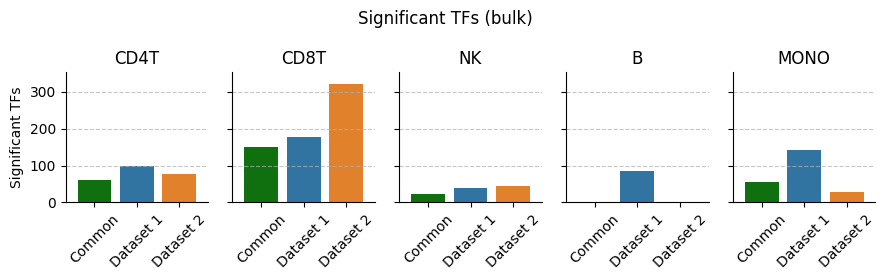

In [93]:
from ciim.src.tf_activity.plots import compare_stats_across_datasets
if True:
    compare_stats_across_datasets(stats_all.rename({'tf': 'gene'}, axis=1), y_label='Significant TFs')
    plt.suptitle('Significant TFs (bulk)', y=1.1)

# Trajectory plot: TF acitvity with age

In [94]:
from ciim.src.tf_activity.plots import plot_trends
if False:
    cell_type = 'CD8T'
    genes = ['KLF6']
    
    plot_trends(genes, tf_acts_dict, cell_type)
    plt.tight_layout()
    plt.savefig(f'../output/tf_activation/trends_{cell_type}_case.png', dpi=300)

# Positive/negative trends, all cell types

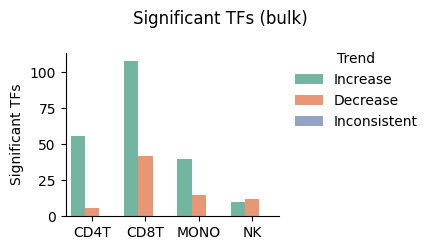

In [95]:
from src.tf_activity.helper import compute_linear_trend
stats_all_sig = compute_linear_trend(stats_all_sig, pval_col='meta_p_adj', slope_col='slope')
df = stats_all_sig[['tf', 'cell_type', 'meta_p_adj', 'linear_trend', 'neg_log10_adj_pval']]
df = df[~df.duplicated()].reset_index(drop=True)
df_counts = df.groupby(['cell_type', 'linear_trend']).size().reset_index(name='Sig. TFs')

fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.5))
sns.barplot(data=df_counts, x='cell_type', y='Sig. TFs', hue='linear_trend', palette='Set2', ax=ax)
ax.set_ylabel('Significant TFs')
ax.set_xlabel('')
ax.legend(loc=(1.05, 0.5), title='Trend', frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.suptitle('Significant TFs (bulk)', fontsize=12)
plt.tight_layout()
plt.savefig(f'../output/tf_activation/trends.png', dpi=300)


# Interaction of sig TFs between different cell types

['CD8T', 'CD4T', 'MONO', 'NK']


Text(0.5, 1.0, 'Significant TFs (bulk)')

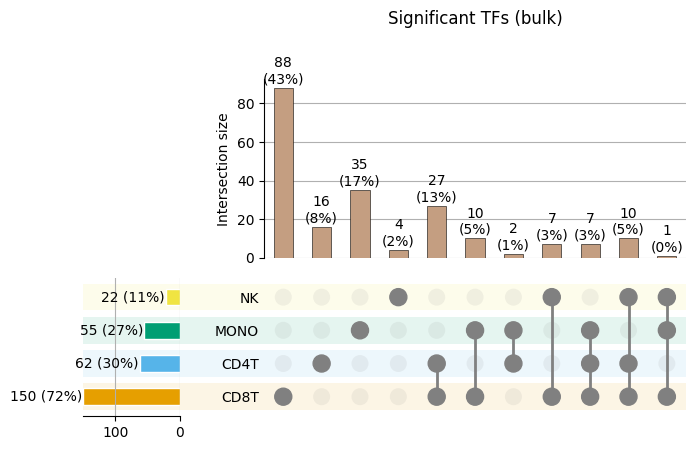

In [96]:
sys.path.append('../../')
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df
df = stats_all_sig.copy()

df_dict = df.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_df = create_interaction_df(df_dict)
aa = plot_interactions(interaction_df, min_subset_size=1)
plt.title('Significant TFs (bulk)', pad=40)

# TF activity trend vs expression in aging

In [97]:
# --------------- add the stats obtained from expression data (rather than TF activity)
from helper import  determine_stats, adata_lambda

stats_store = []
for dataset in datasets:
    adata = adata_lambda(dataset)
    for cell_type in cell_types:
        print(f'dataset: {dataset}, cell_type: {cell_type}')
        stats_all_sig_df = stats_all_sig[stats_all_sig['cell_type'] == cell_type]
        adata_sub = adata[adata.obs['cell_type'] == cell_type]
        sig_tfs = stats_all_sig_df['tf'].unique()
        sig_tfs_median_expression = np.median(adata_sub[:, sig_tfs].X.toarray(), axis=0)
        stats = []
        for tf, median_expression in zip(sig_tfs, sig_tfs_median_expression):
            stats.append({'tf': tf, 'median_expression': median_expression})
        stats = pd.DataFrame(stats)
        stats['dataset'] = dataset
        stats['cell_type'] = cell_type
        stats_store.append(stats)
expression_df = pd.concat(stats_store).reset_index(drop=True)
expression_df.head()

dataset: data1, cell_type: CD4T
dataset: data1, cell_type: CD8T
dataset: data1, cell_type: NK
dataset: data1, cell_type: B
dataset: data1, cell_type: MONO
dataset: data7_allTPs_jalil, cell_type: CD4T
dataset: data7_allTPs_jalil, cell_type: CD8T
dataset: data7_allTPs_jalil, cell_type: NK
dataset: data7_allTPs_jalil, cell_type: B
dataset: data7_allTPs_jalil, cell_type: MONO


,tf,median_expression,dataset,cell_type
0,BATF,2.309879,data1,CD4T
1,NPDC1,2.323331,data1,CD4T
2,RAN,4.313681,data1,CD4T
3,SP140,2.511806,data1,CD4T
4,ID2,4.124556,data1,CD4T


In [98]:
df_all = compute_linear_trend(stats_all_sig, pval_col='meta_p_adj', slope_col='slope')[['tf', 'cell_type', 'meta_p_adj', 'linear_trend', 'neg_log10_adj_pval', 'dataset']]

df_all = df_all.merge(expression_df, on=['tf', 'cell_type', 'dataset'], how='left')

df_all.head(5)

,tf,cell_type,meta_p_adj,linear_trend,neg_log10_adj_pval,dataset,median_expression
0,BATF,CD4T,0.000001,Increase,5.874151,data1,2.309879
1,NPDC1,CD4T,0.000014,Increase,4.840654,data1,2.323331
2,RAN,CD4T,0.013590,Increase,1.866765,data1,4.313681
3,SP140,CD4T,0.003055,Increase,2.514942,data1,2.511806
4,ID2,CD4T,0.001865,Increase,2.729244,data1,4.124556


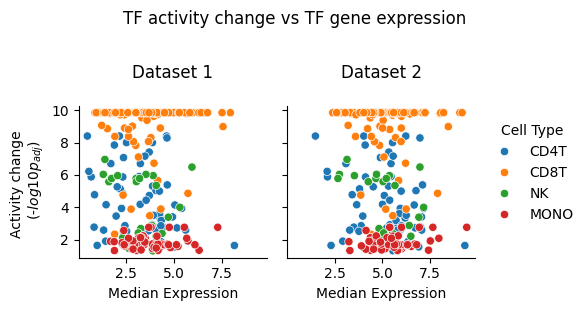

In [99]:
df = df_all
datasets = df["dataset"].unique()
n_datasets = len(datasets)

# Set up subplots
fig, axes = plt.subplots(1, n_datasets, figsize=(3 * n_datasets, 3), sharex=True, sharey=True)

# Loop through datasets and create scatter plots
for ax, dataset in zip(axes, datasets):
    subset = df[df["dataset"] == dataset]
    sns.scatterplot(data=subset, x="median_expression", y="neg_log10_adj_pval", hue="cell_type", ax=ax, legend=True)
    
    ax.set_title(surrogate_names[dataset], pad=20)
    ax.set_xlabel("Median Expression")
    ax.set_ylabel("Activity change \n (-$log10{p_{adj}}$)")
    ax.spines[['top', 'right']].set_visible(False)
    ax.get_legend().remove()
ax.legend(loc=(1.05, 0.2), title="Cell Type", frameon=False)
plt.suptitle("TF activity change vs TF gene expression", y=1.02)
plt.tight_layout()
plt.show()

# TF activity trend vs expression trend in aging

In [100]:
# --------------- add the stats obtained from expression data (rather than TF activity)
from helper import  determine_stats, adata_lambda

stats_store = []
for dataset in datasets:
    adata = adata_lambda(dataset)
    for cell_type in cell_types:
        print(f'dataset: {dataset}, cell_type: {cell_type}')
        stats_all_sig_df = stats_all_sig[stats_all_sig['cell_type'] == cell_type]
        adata_sub = adata[adata.obs['cell_type'] == cell_type]
        sig_tfs = stats_all_sig_df['tf'].unique()
    
        stats = determine_stats(adata_sub, sig_tfs)
        stats['dataset'] = dataset
        stats['cell_type'] = cell_type
        stats_store.append(stats)
expression_stats_all = pd.concat(stats_store).reset_index(drop=True)
expression_stats_all.head()

dataset: data1, cell_type: CD4T
dataset: data1, cell_type: CD8T
dataset: data1, cell_type: NK
dataset: data1, cell_type: B
dataset: data1, cell_type: MONO
dataset: data7_allTPs_jalil, cell_type: CD4T
dataset: data7_allTPs_jalil, cell_type: CD8T
dataset: data7_allTPs_jalil, cell_type: NK
dataset: data7_allTPs_jalil, cell_type: B
dataset: data7_allTPs_jalil, cell_type: MONO


,tf,p_value,p_value_adj,slope,r2,intercept,spearman_corr,spearman_p,dataset,cell_type
0,BATF,5.950575e-01,1.000000e+00,0.000336,0.000289,2.270334,-0.009412,7.684351e-01,data1,CD4T
1,NPDC1,5.416247e-08,3.358073e-06,0.004843,0.029759,1.974766,0.188135,2.882313e-09,data1,CD4T
2,RAN,5.946844e-01,1.000000e+00,0.000244,0.000289,4.302136,0.008894,7.808339e-01,data1,CD4T
3,SP140,5.364233e-23,3.325825e-21,0.004247,0.094846,2.238258,0.291815,1.037567e-20,data1,CD4T
4,ID2,1.207088e-02,7.483944e-01,-0.001640,0.006418,4.230078,-0.073711,2.094906e-02,data1,CD4T


In [101]:
# - merge activation with expression sig stats
stats_all_sig_combined = stats_all_sig.merge(expression_stats_all[['tf', 'slope', 'p_value', 'dataset', 'cell_type']], on=['tf', 'cell_type' ,'dataset'], suffixes=('', '_expression'), how='left')
stats_all_sig_combined.head()

,tf,p_value,p_value_adj,slope,r2,intercept,spearman_corr,spearman_p,dataset,cell_type,meta_p,meta_p_adj,neg_log10_adj_pval,slope_expression,p_value_expression
0,BATF,2.297722e-07,3.745286e-05,0.002974,0.026982,-5.336612,0.138317,1.376276e-05,data1,CD4T,2.298722e-07,0.000001,5.874151,0.000336,5.950575e-01
1,NPDC1,3.569265e-06,5.817901e-04,0.004286,0.021716,0.537752,0.119086,1.851758e-04,data1,CD4T,3.569365e-06,0.000014,4.840654,0.004843,5.416247e-08
2,RAN,8.037382e-03,1.000000e+00,0.005127,0.007154,20.640552,0.067092,3.563447e-02,data1,CD4T,8.037382e-03,0.013590,1.866765,0.000244,5.946844e-01
3,SP140,2.506912e-13,4.086267e-11,0.000225,0.053267,0.328931,0.194373,8.313074e-10,data1,CD4T,1.741207e-03,0.003055,2.514942,0.004247,5.364233e-23
4,ID2,1.889896e-09,3.080531e-07,0.001217,0.036205,1.474842,0.162777,2.958854e-07,data1,CD4T,8.825234e-04,0.001865,2.729244,-0.001640,1.207088e-02


In [102]:
stats_all_sig_combined['signed_-log10_pval'] = (-np.log10(stats_all_sig_combined['p_value'])) * np.sign(stats_all_sig_combined['slope'])
stats_all_sig_combined['signed_-log10_pval_exp'] = (-np.log10(stats_all_sig_combined['p_value_expression'])) * np.sign(stats_all_sig_combined['slope_expression'])

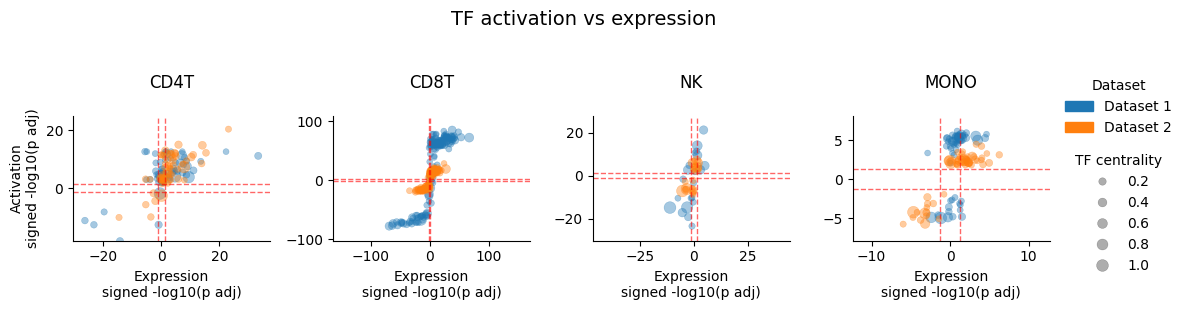

In [103]:
from src.tf_activity.plots import plot_activation_vs_expression

plot_activation_vs_expression(stats_all_sig_combined)
plt.suptitle("TF activation vs expression", y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(f'../output/tf_activation/activation_vs_expression.png', dpi=300)

# TF-gene interactions 

## Consensus net across datasets


In [104]:
sig_nets_dict = {}
for cell_type in stats_all_sig['cell_type'].unique():
    net = consensus_nets_dict[cell_type]
    net = net[net['source'].isin(sig_tfs)]
    
    sig_nets_dict[cell_type] = net

## In-degree centrality of target genes

In [105]:
from ciim.src.helper import determine_centrality

top_target_n = 20
top_targets_df = []
for i, (cell_type, net_o) in enumerate(sig_nets_dict.items()):
    # - determine in-degree centality
    net = net_o.copy()
    net['source_'] = net['source']
    net['source'] = net['target']
    net['target'] = net['source_']
    net.drop('source_', axis=1, inplace=True)

    c = determine_centrality(net, use_weight=False)
    c = c.sort_values('centrality', ascending=False)[:top_target_n]
    c['cell_type'] = cell_type
    top_targets_df.append(c)
top_targets_df = pd.concat(top_targets_df)
top_targets_df['is_tf'] = top_targets_df.index.isin(tf_all)
top_targets_df['is_tf'] = top_targets_df['is_tf'].replace({True: 'TF', False: 'Non-TF'})
top_targets_df['is_tf'] = top_targets_df['is_tf'].astype('category')
top_targets_df.head()

,centrality,cell_type,is_tf
FOS,0.589928,CD4T,TF
FOSB,0.215827,CD4T,TF
JUND,0.201439,CD4T,TF
PSMA6,0.122302,CD4T,TF
BAX,0.093525,CD4T,TF


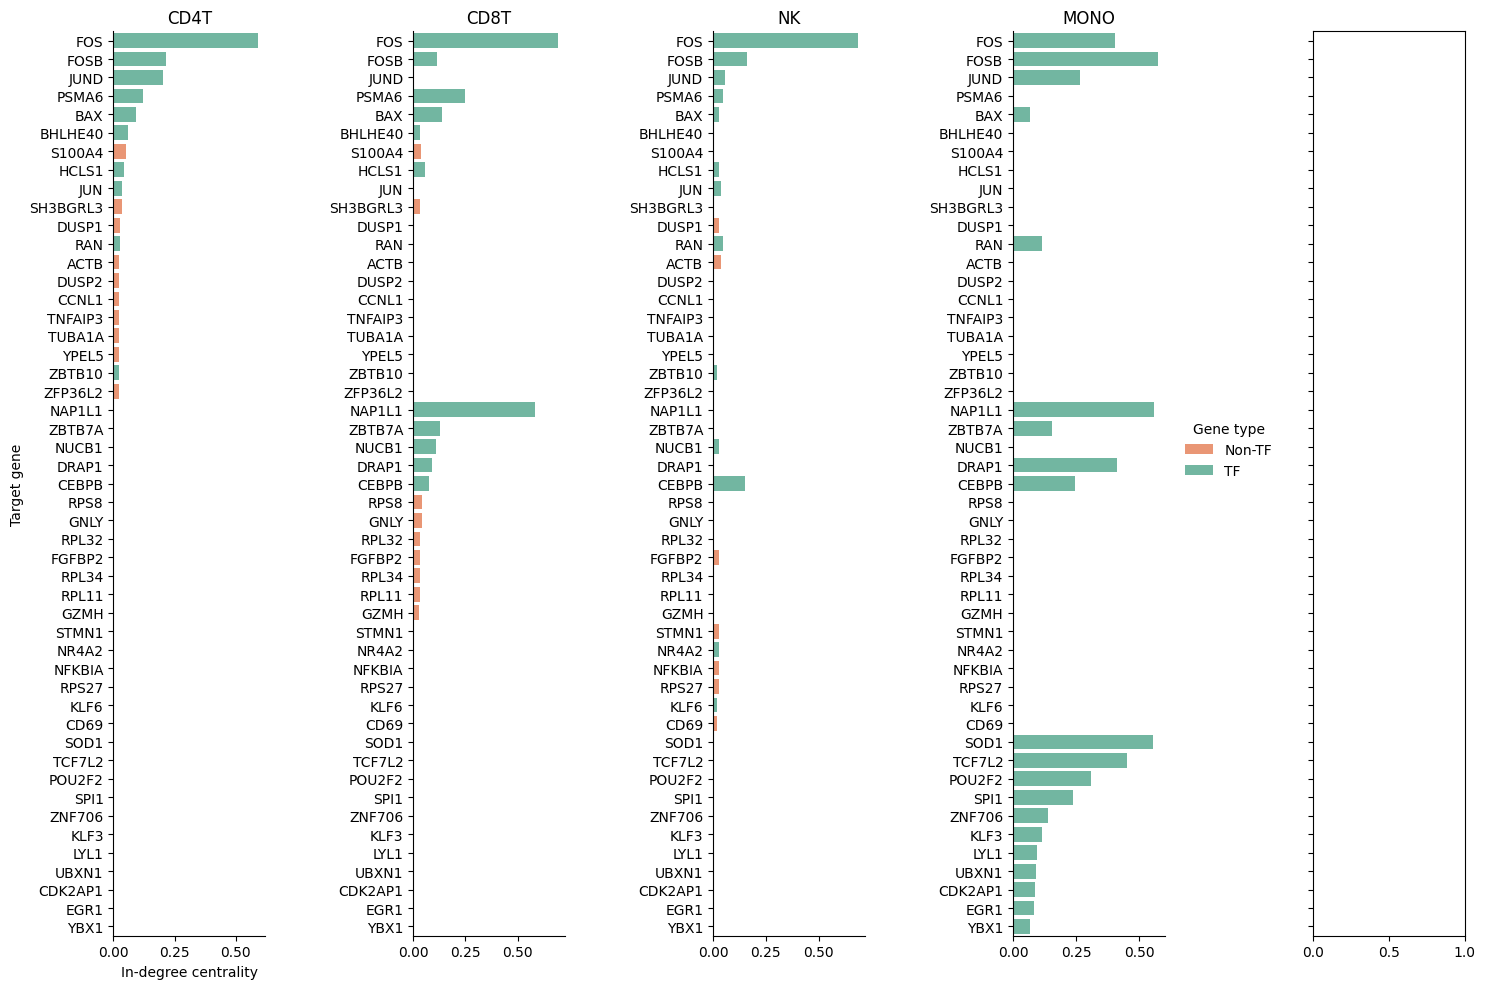

In [106]:
fig, axes = plt.subplots(1, 5, figsize=(15, 10), sharey=True)
for i, (cell_type) in enumerate(top_targets_df['cell_type'].unique()):
    c = top_targets_df[top_targets_df['cell_type'] == cell_type]
    palette = {key:color for key, color in zip(['TF', 'Non-TF'], sns.color_palette("Set2", 2))} 
    ax = axes[i]
    sns.barplot(data=c, x='centrality', y=c.index, hue='is_tf', dodge=False, ax=ax, palette=palette)

    ax.set_ylabel('Target gene' if i == 0 else "")  # Only label the first plot
    ax.set_xlabel('In-degree centrality')
    ax.set_title(cell_type)
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params(labelleft=True)
    ax.get_legend().remove()  # Remove legend from individual plot
    if i != 0:
        ax.set_ylabel('')
        ax.set_xlabel('')
ax.legend(title="Gene type", loc=(1.1, 0.5), frameon=False)

plt.tight_layout()

## Dotplot for TF-target intereactions

In [107]:
# - determine the significance of the change in expression for the targets
from ciim.src.tf_activity.script import determine_stats_targets_bulk
if True:
    # Compute expression change significance once for all targets across all cell types
    cell_types_local = sig_nets_dict.keys()
    stats_targets_all = []
    for cell_type in cell_types_local:
        print(f"Processing {cell_type}")
        targets = sig_nets_dict[cell_type]['target'].unique()
        stats_t = determine_stats_targets_bulk(targets, cell_type, datasets)
        stats_targets_all.append(stats_t)

    # Concatenate results
    stats_targets_all = pd.concat(stats_targets_all)

    # Call `wrapper_meta_analysis` once for all data
    stats_targets_c = stats_targets_all.rename(columns={'p_value': 'pvalue', 'target': 'gene'})
    df_meta_all = wrapper_meta_analysis(stats_targets_c)
    df_meta_all.rename(columns={'gene': 'target'}, inplace=True)

    # Merge the meta-analysis results back to original stats
    stats_targets_all = stats_targets_all.merge(df_meta_all, on=['target', 'cell_type'], how='left')
stats_targets_all.head()

Processing CD4T
Processing CD8T
Processing NK
Processing MONO
CD4T (56, 4)
CD8T (246, 4)
NK (58, 4)
MONO (709, 4)
4


,target,p_value,p_value_adj,slope,r2,intercept,spearman_corr,spearman_p,dataset,cell_type,meta_p,meta_p_adj
0,ACTB,0.019949,1.000000,-0.001081,0.005520,7.193894,-0.068994,0.030713,data1,CD4T,NaN,NaN
1,B2M,0.001092,0.137577,0.000725,0.010840,8.639039,0.106161,0.000868,data1,CD4T,0.001092,0.004076
2,IL32,0.000092,0.011577,0.002157,0.015511,5.925917,0.109159,0.000615,data1,CD4T,0.000092,0.000429
3,PFN1,0.735194,1.000000,-0.000118,0.000117,6.234164,0.000582,0.985486,data1,CD4T,NaN,NaN
4,PHPT1,0.000002,0.000252,0.001651,0.022826,3.074024,0.136763,0.000017,data1,CD4T,0.000002,0.000011


In [108]:
from ciim.src.tf_activity.plots import DotPlotTFtarget

obj = DotPlotTFtarget(tf_all, skeleton)

data_all = obj.wrapper_combine_data(stats_all_sig, stats_targets_all, sig_nets_dict)


CD4T
CD8T
NK
MONO


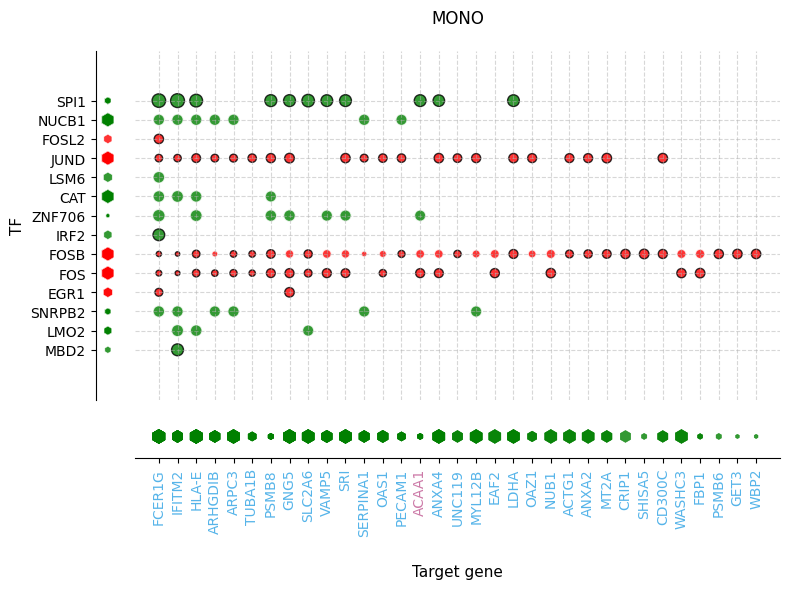

In [109]:
obj.plot_dotplot(data_all[data_all['cell_type']=='MONO'], title='MONO', figsize=(8, 6), height_ratios=(4, .5), width_ratios=[0.15, 4], ax_main_margin=(0.04, .2))

# GSEA

In [110]:
# remove those that were not consistent 
df = compute_linear_trend(stats_all_sig, pval_col='meta_p_adj', slope_col='slope')[['tf', 'cell_type', "meta_p_adj", 'linear_trend', 'neg_log10_adj_pval']]

stats_all_sig_consistent = df[df['linear_trend'] != 'Inconsistent']
stats_all_sig_consistent.head(5)

,tf,cell_type,meta_p_adj,linear_trend,neg_log10_adj_pval
0,BATF,CD4T,0.000001,Increase,5.874151
1,NPDC1,CD4T,0.000014,Increase,4.840654
2,RAN,CD4T,0.013590,Increase,1.866765
3,SP140,CD4T,0.003055,Increase,2.514942
4,ID2,CD4T,0.001865,Increase,2.729244


## Canonical 

In [111]:
from ciim.src.tf_activity.helper import pathway_analysis_wrapper
pathway_scores = pathway_analysis_wrapper(stats_all_sig_consistent)

cell_type: CD4T, trend: Increase, n tfs: 56
cell_type: CD4T, trend: Decrease, n tfs: 6
cell_type: CD8T, trend: Increase, n tfs: 108
cell_type: CD8T, trend: Decrease, n tfs: 42
cell_type: NK, trend: Increase, n tfs: 10
cell_type: NK, trend: Decrease, n tfs: 12
cell_type: MONO, trend: Increase, n tfs: 40
cell_type: MONO, trend: Decrease, n tfs: 15


In [112]:
terms = pathway_scores.groupby(['cell_type'])['Term'].apply(list)
print('MONO:', terms['MONO'])
print('NK:',terms['NK'])
print('CD4T:',terms['CD4T'])
print('CD8T:',terms['CD8T'])

MONO: ['Reactive Oxygen Species Pathway', 'Myc Targets V1', 'heme Metabolism', 'Interferon Alpha Response', 'Pancreas Beta Cells', 'Adipogenesis', 'Interferon Gamma Response', 'Protein Secretion', 'TNF-alpha Signaling via NF-kB', 'TGF-beta Signaling', 'Hypoxia', 'UV Response Dn', 'Estrogen Response Early', 'UV Response Up', 'p53 Pathway']
NK: ['Apoptosis', 'IL-2/STAT5 Signaling', 'Wnt-beta Catenin Signaling', 'TNF-alpha Signaling via NF-kB', 'Apoptosis', 'KRAS Signaling Up', 'Complement']
CD4T: ['Apoptosis', 'TNF-alpha Signaling via NF-kB', 'Hypoxia', 'TGF-beta Signaling', 'IL-2/STAT5 Signaling', 'E2F Targets', 'UV Response Dn', 'Reactive Oxygen Species Pathway', 'Wnt-beta Catenin Signaling', 'Apoptosis']
CD8T: ['TNF-alpha Signaling via NF-kB', 'TGF-beta Signaling', 'IL-2/STAT5 Signaling', 'Hypoxia', 'Apoptosis', 'mTORC1 Signaling', 'Interferon Alpha Response', 'Unfolded Protein Response', 'Estrogen Response Early', 'Interferon Gamma Response', 'Myc Targets V1', 'TNF-alpha Signaling vi

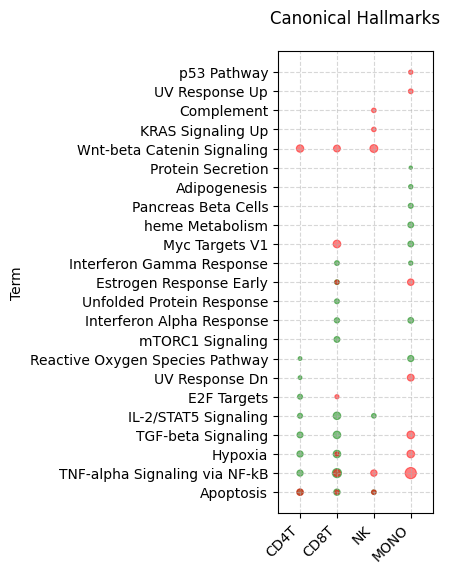

In [113]:
from ciim.src.tf_activity.plots import plot_enrich

# Create figure
fig, ax = plt.subplots(figsize=(2, 6))
plot_enrich(pathway_scores, ax)
plt.title("Canonical Hallmarks", pad=20)
# plt.tight_layout()
plt.show()

# Single cell TF activation

## Run to get std of TF activation using single cell data

In [114]:
from ciim.src.tf_activity.script import determine_stats_std_tf_activation
import pandas as pd
import os

cell_types = ['CD4T', 'CD8T', 'NK', 'B', 'MONO']

par = {
    # - global vars
    'datasets': ['data1', 'data7_allTPs_jalil'], # data7_allTPs_jalil
    'central_tf_q': .8,
    'predictor_age_q': .8,
    'temp_dir': '../output/tf_activation/temp',
}

os.makedirs(par['temp_dir'], exist_ok=True)
datasets = par['datasets']
if False:
# # --------- run
    stats_df_store = []
    for cell_type in cell_types:
        par['cell_type'] = cell_type
        stats_df = determine_stats_std_tf_activation(par)
        stats_df['cell_type'] = cell_type
        stats_df_store.append(stats_df)
    stats_all_std = pd.concat(stats_df_store)
    stats_all_std.to_csv('../output/tf_activation/stats_all_sc.csv', index=False)
else:
    stats_all_std = pd.read_csv('../output/tf_activation/stats_all_sc.csv')

## Meta analysis

In [115]:
# - meta analysis
from ciim.src.tf_activity.meta_analysis.helper import wrapper_meta_analysis
stats_all_c = stats_all_std.copy()
stats_all_c.rename(columns={'p_value': 'pvalue', 'tf':'gene'}, inplace=True)
df_meta_all_sc = wrapper_meta_analysis(stats_all_c)
df_meta_all_sc.rename(columns={'gene': 'tf'}, inplace=True)

# - merge
assert 'meta_p_adj' not in stats_all_std.columns, 'meta_p_adj already in df_meta_all'
stats_all_std = stats_all_std.merge(df_meta_all_sc, on=['tf', 'cell_type'], how='left')
stats_all_std_sig = stats_all_std[stats_all_std['meta_p_adj'] < 0.05]
stats_all_std_sig.head()

CD4T (97, 4)
CD8T (131, 4)
NK (8, 4)
B (45, 4)
MONO (222, 4)
5


,tf,p_value,p_value_adj,slope,r2,intercept,spearman_corr,spearman_p,dataset,cell_type,meta_p,meta_p_adj
503,ANXA1,2.074433e-06,0.000390,-0.139920,0.022757,56.520803,-0.187271,3.412830e-09,data1,CD8T,2.074533e-06,0.000006
505,APEX1,2.812595e-02,1.000000,-0.017127,0.004914,13.157442,-0.096226,2.552413e-03,data1,CD8T,2.812595e-02,0.030704
506,ARID5B,7.830214e-07,0.000147,-0.029269,0.024627,11.633473,-0.193551,9.817592e-10,data1,CD8T,7.831214e-07,0.000003
507,ASCL2,1.243226e-04,0.023373,-0.112919,0.014937,55.470975,-0.155787,9.431938e-07,data1,CD8T,1.243227e-04,0.000170
509,ATF6B,1.018424e-05,0.001915,-0.006752,0.019708,3.479413,-0.173112,4.860259e-08,data1,CD8T,1.018434e-05,0.000021


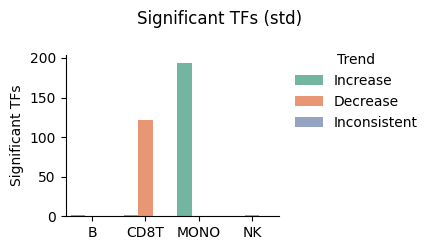

In [116]:
from src.tf_activity.helper import compute_linear_trend
stats_all_std_sig = compute_linear_trend(stats_all_std_sig, pval_col='meta_p_adj', slope_col='slope')
df = stats_all_std_sig[['tf', 'cell_type', 'meta_p_adj', 'linear_trend', 'neg_log10_adj_pval']]
df = df[~df.duplicated()].reset_index(drop=True)
df_counts = df.groupby(['cell_type', 'linear_trend']).size().reset_index(name='Sig. TFs')

fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.5))
sns.barplot(data=df_counts, x='cell_type', y='Sig. TFs', hue='linear_trend', palette='Set2', ax=ax)
ax.set_ylabel('Significant TFs')
ax.set_xlabel('')
ax.legend(loc=(1.05, 0.5), title='Trend', frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.suptitle('Significant TFs (std)', fontsize=12)
plt.tight_layout()
plt.savefig(f'../output/tf_activation/trends_std.png', dpi=300)


Text(0.5, 1.1, 'Significant TFs (std)')

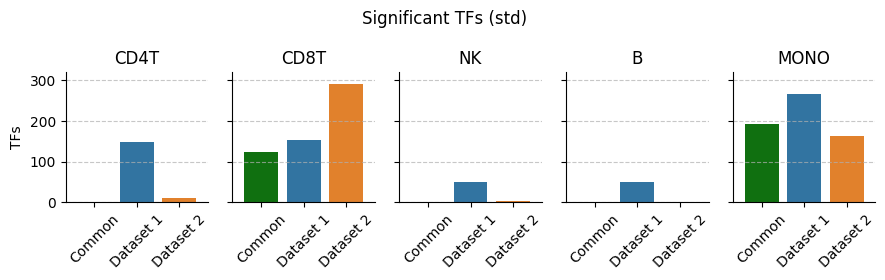

In [117]:
compare_stats_across_datasets(stats_all_std.rename({'tf': 'gene'}, axis=1))
plt.suptitle('Significant TFs (std)', y=1.1)

['MONO', 'CD8T', 'NK', 'B']


Text(0.5, 1.0, 'Significant TFs (std)')

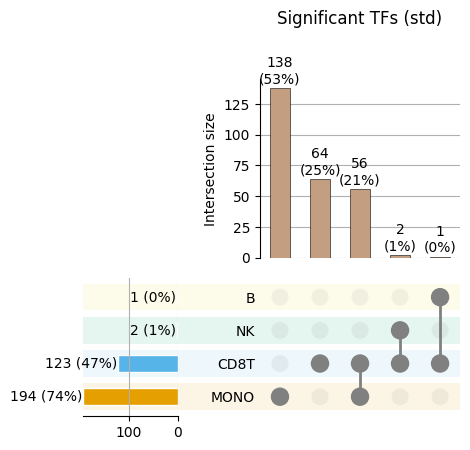

In [118]:
df = stats_all_std_sig.copy()

df_dict = df.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_df = create_interaction_df(df_dict)
aa = plot_interactions(interaction_df, min_subset_size=1)
plt.title('Significant TFs (std)', pad=40)

## Combine stats of the std of TF activation with TF activation

In [119]:
# - merge std stats with activation stats
stats_all_sig_combined = stats_all_std_sig.merge(stats_all_sig[['tf', 'slope', 'p_value', 'dataset', 'cell_type']], on=['tf', 'cell_type' ,'dataset'], suffixes=('_std', '_bulk'), how='left')
stats_all_sig_combined.head()

,tf,p_value_std,p_value_adj,slope_std,r2,intercept,spearman_corr,spearman_p,dataset,cell_type,meta_p,meta_p_adj,neg_log10_adj_pval,linear_trend,slope_bulk,p_value_bulk
0,ANXA1,2.074433e-06,0.000390,-0.139920,0.022757,56.520803,-0.187271,3.412830e-09,data1,CD8T,2.074533e-06,0.000006,5.199277,Decrease,0.179365,1.965854e-72
1,APEX1,2.812595e-02,1.000000,-0.017127,0.004914,13.157442,-0.096226,2.552413e-03,data1,CD8T,2.812595e-02,0.030704,1.512803,Decrease,-0.010163,1.231448e-60
2,ARID5B,7.830214e-07,0.000147,-0.029269,0.024627,11.633473,-0.193551,9.817592e-10,data1,CD8T,7.831214e-07,0.000003,5.568683,Decrease,0.009051,6.742313e-82
3,ASCL2,1.243226e-04,0.023373,-0.112919,0.014937,55.470975,-0.155787,9.431938e-07,data1,CD8T,1.243227e-04,0.000170,3.770450,Decrease,0.105239,3.411372e-61
4,ATF6B,1.018424e-05,0.001915,-0.006752,0.019708,3.479413,-0.173112,4.860259e-08,data1,CD8T,1.018434e-05,0.000021,4.680976,Decrease,0.000632,4.792666e-69


In [120]:
stats_all_sig_combined['signed_-log10_pval_std'] = ((-np.log10(stats_all_sig_combined['p_value_std'])) * np.sign(stats_all_sig_combined['slope_std'])).fillna(0)
stats_all_sig_combined['signed_-log10_pval_bulk'] = ((-np.log10(stats_all_sig_combined['p_value_bulk'])) * np.sign(stats_all_sig_combined['slope_bulk'])).fillna(0)

## Plot std vs mean of TF activation stats

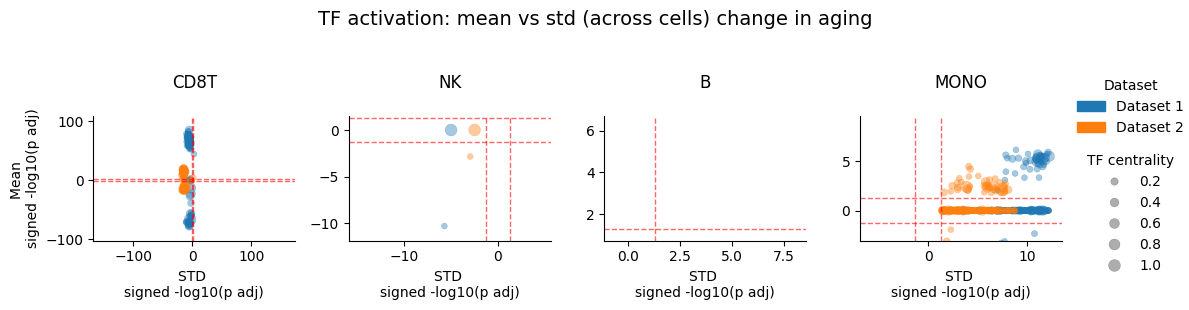

In [121]:

plot_activation_vs_expression(stats_all_sig_combined, 
                                  col_x = 'signed_-log10_pval_std', 
                                  col_y = 'signed_-log10_pval_bulk', 
                                  y_label = "Mean \nsigned -log10(p adj)",
                                  x_label = "STD \nsigned -log10(p adj)")

plt.suptitle("TF activation: mean vs std (across cells) change in aging", y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(f'../output/tf_activation/activation_vs_std.png', dpi=300)

## Dotplot TF-target interactions

In [122]:
### Determine stats of std of gene expression 
from ciim.src.tf_activity.script import determine_stats_std_targets_sc

if True:
    # Compute expression change significance once for all targets
    stats_std_targets = []
    for cell_type in cell_types:
        temp_save_file = f'../output/tf_activation/stats_std_targets_{cell_type}.csv' #TODO: remove this
        if os.path.exists(temp_save_file):
            stats_t = pd.read_csv(temp_save_file)
        else:
            print(f"Computing stats for {cell_type}")
            targets = consensus_nets_dict[cell_type]['target'].unique()
            stats_t = determine_stats_std_targets_sc(targets, cell_type, datasets)
            stats_t['cell_type'] = cell_type
            stats_t.to_csv(temp_save_file, index=False)
        
        stats_std_targets.append(stats_t)
    # Concatenate results
    stats_std_targets_all = pd.concat(stats_std_targets)
stats_std_targets_all

,target,p_value,p_value_adj,slope,r2,intercept,spearman_corr,spearman_p,dataset,cell_type
0,ALOX5AP,6.715388e-268,3.035356e-265,0.001662,0.001980,0.156373,0.041326,2.645365e-231,data1,CD4T
1,ANXA2,4.536447e-116,2.050474e-113,0.001338,0.000850,0.132688,0.035770,8.972957e-174,data1,CD4T
2,B2M,0.000000e+00,0.000000e+00,0.175670,0.012578,30.246992,0.111791,0.000000e+00,data1,CD4T
3,CAPG,4.049401e-136,1.830329e-133,0.000574,0.000999,0.033095,0.029536,4.241563e-119,data1,CD4T
4,CCR10,1.254943e-16,5.672343e-14,0.000125,0.000111,0.008381,0.011729,3.181742e-20,data1,CD4T
...,...,...,...,...,...,...,...,...,...,...
2779,TRAPPC1,6.097897e-148,8.488273e-145,0.002432,0.002084,0.555012,0.046788,2.604423e-155,data7_allTPs_jalil,MONO
2780,C1orf122,6.764933e-16,9.416787e-13,0.000321,0.000203,0.113381,0.014833,4.006836e-17,data7_allTPs_jalil,MONO
2781,SSU72,1.141431e-36,1.588873e-33,0.000847,0.000497,0.322495,0.022450,3.842822e-37,data7_allTPs_jalil,MONO
2782,ACTR2,1.031126e-62,1.435327e-59,0.002489,0.000868,1.269199,0.034608,8.113526e-86,data7_allTPs_jalil,MONO


In [123]:
from ciim.src.tf_activity.meta_analysis.helper import wrapper_meta_analysis

# - meta analysis
stats_c = stats_std_targets_all.copy()
stats_c.rename(columns={'p_value': 'pvalue', 'target':'gene'}, inplace=True)
df_meta = wrapper_meta_analysis(stats_c)
df_meta.rename(columns={'gene': 'target'}, inplace=True)
df_meta.head()

CD4T (230, 4)
CD8T (752, 4)
NK (154, 4)
B (119, 4)
MONO (1093, 4)
5


,target,meta_p,meta_p_adj,cell_type
0,ACTB,1.000000e-10,1.334997e-10,CD4T
1,ACTG1,1.000000e-10,1.334997e-10,CD4T
2,ACTN4,1.000000e-10,1.334997e-10,CD4T
3,ADAM19,1.000000e-10,1.334997e-10,CD4T
4,ADTRP,1.000000e-10,1.334997e-10,CD4T


In [124]:
# - merge them
stats_std_targets_all = stats_std_targets_all.merge(df_meta, on=['target', 'cell_type'], how='left')
stats_std_targets_all.head()


,target,p_value,p_value_adj,slope,r2,intercept,spearman_corr,spearman_p,dataset,cell_type,meta_p,meta_p_adj
0,ALOX5AP,6.715388e-268,3.035356e-265,0.001662,0.001980,0.156373,0.041326,2.645365e-231,data1,CD4T,1.000000e-10,1.334997e-10
1,ANXA2,4.536447e-116,2.050474e-113,0.001338,0.000850,0.132688,0.035770,8.972957e-174,data1,CD4T,1.000000e-10,1.334997e-10
2,B2M,0.000000e+00,0.000000e+00,0.175670,0.012578,30.246992,0.111791,0.000000e+00,data1,CD4T,1.000000e-10,1.334997e-10
3,CAPG,4.049401e-136,1.830329e-133,0.000574,0.000999,0.033095,0.029536,4.241563e-119,data1,CD4T,1.000000e-10,1.334997e-10
4,CCR10,1.254943e-16,5.672343e-14,0.000125,0.000111,0.008381,0.011729,3.181742e-20,data1,CD4T,1.000001e-10,1.334997e-10


In [125]:
sig_nets_dict = {}
for cell_type in stats_all_std_sig['cell_type'].unique():
    net = consensus_nets_dict[cell_type]
    sig_tfs = stats_all_std_sig[stats_all_std_sig['cell_type'] == cell_type]['tf'].unique()
    net = net[net['source'].isin(sig_tfs)]
    
    sig_nets_dict[cell_type] = net

In [126]:
from ciim.src.tf_activity.plots import DotPlotTFtarget

obj = DotPlotTFtarget(tf_all, skeleton)

data_all = obj.wrapper_combine_data(stats_all_std_sig, stats_std_targets_all, sig_nets_dict)

CD8T
NK
B
MONO


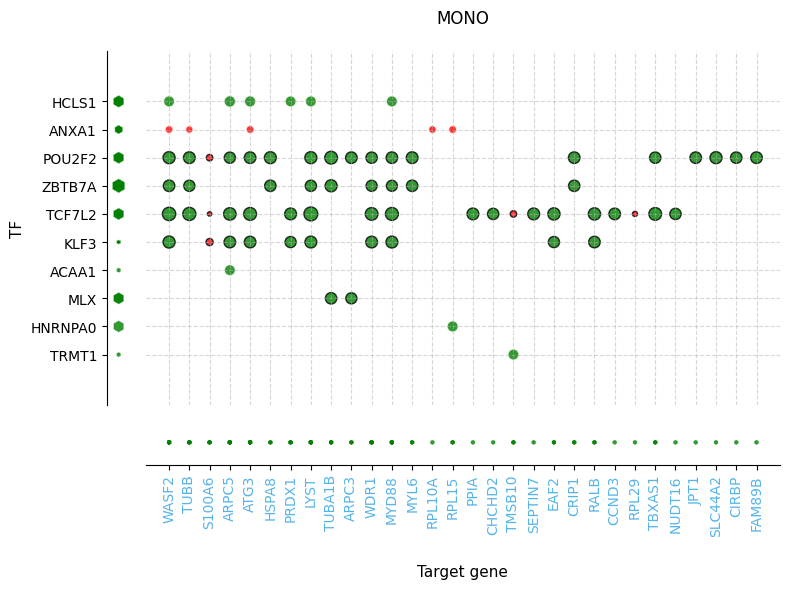

In [127]:
obj.plot_dotplot(data_all[data_all['cell_type']=='MONO'], title='MONO', figsize=(8, 6), height_ratios=(4, .5), width_ratios=[0.15, 4], ax_main_margin=(0.04, .2))

## Pathway analysis

In [128]:
stats_all_std_sig_consistent = stats_all_std_sig[stats_all_std_sig['linear_trend'] != 'Inconsistent']

In [129]:
from ciim.src.tf_activity.helper import pathway_analysis_wrapper
pathway_scores_std = pathway_analysis_wrapper(stats_all_std_sig_consistent)
pathway_scores_std.head()


cell_type: CD8T, trend: Decrease, n tfs: 122
cell_type: CD8T, trend: Increase, n tfs: 1
cell_type: NK, trend: Decrease, n tfs: 2
cell_type: B, trend: Increase, n tfs: 1
cell_type: MONO, trend: Increase, n tfs: 194


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,cell_type,linear_trend
0,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,14/200,2.100627e-11,8.822634e-10,0,0,13.724014,337.421362,KLF10;CEBPB;CEBPD;FOS;KLF2;FOSL2;KLF6;MYC;IRF1...,CD8T,Decrease
1,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,9/199,3.691515e-06,5.384175e-05,0,0,8.253004,103.240738,EOMES;PRNP;XBP1;KLF6;MYC;BHLHE40;RORA;IKZF2;BATF,CD8T,Decrease
2,MSigDB_Hallmark_2020,Hypoxia,9/200,3.845839e-06,5.384175e-05,0,0,8.209378,102.358780,KLF7;PRDX5;KLF6;TPI1;HSPA5;BHLHE40;RORA;FOS;FOSL2,CD8T,Decrease
3,MSigDB_Hallmark_2020,Apoptosis,8/161,6.556923e-06,6.884769e-05,0,0,9.047128,107.977369,ANXA1;SATB1;FEZ1;IRF1;LEF1;HMGB2;BAX;CTNNB1,CD8T,Decrease
4,MSigDB_Hallmark_2020,Myc Targets V1,8/200,3.160741e-05,2.655023e-04,0,0,7.195175,74.557263,PSMA6;MYC;APEX1;CANX;NAP1L1;HNRNPA1;RPS10;RPL6,CD8T,Decrease


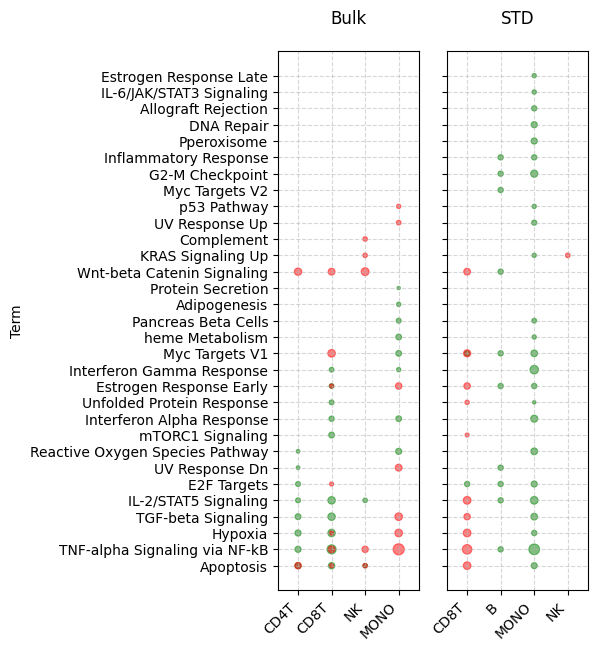

In [130]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(4, 7), sharey=True)
ax = axes[0]
plot_enrich(pathway_scores, ax)
ax.set_title("Bulk", pad=20)
ax = axes[1]
plot_enrich(pathway_scores_std, ax)
ax.set_title("STD", pad=20)
ax.set_ylabel('')
# plt.tight_layout()
plt.show()